In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn streamlit joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\aarya\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from imblearn.over_sampling import SMOTE

import joblib

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print("Shape:", df.shape)

Shape: (284807, 31)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 1081


In [8]:
df = df.drop_duplicates()

print(df.shape)

(283726, 31)


In [9]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

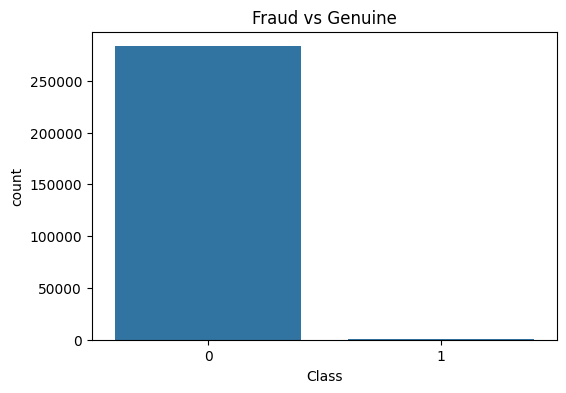

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df["Class"]
)

plt.title("Fraud vs Genuine")
plt.show()

In [11]:
fraud_percent = (
    df["Class"].value_counts(normalize=True)
    *100
)

fraud_percent

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

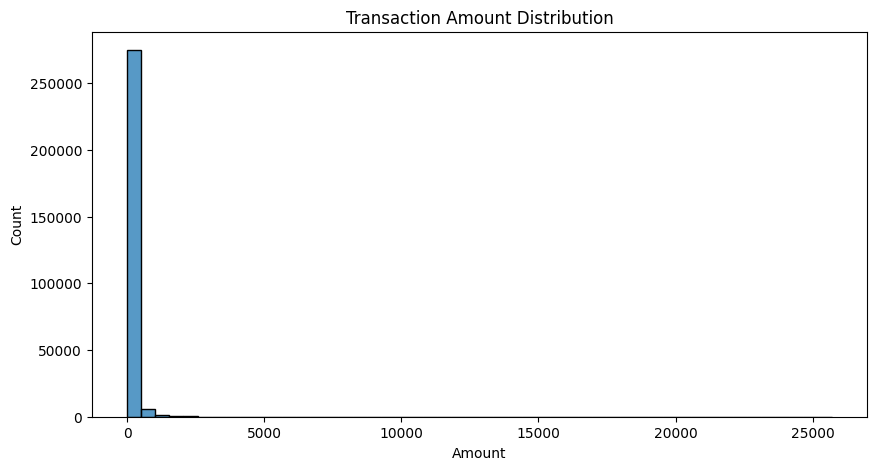

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Amount"],
    bins=50
)

plt.title("Transaction Amount Distribution")

plt.show()

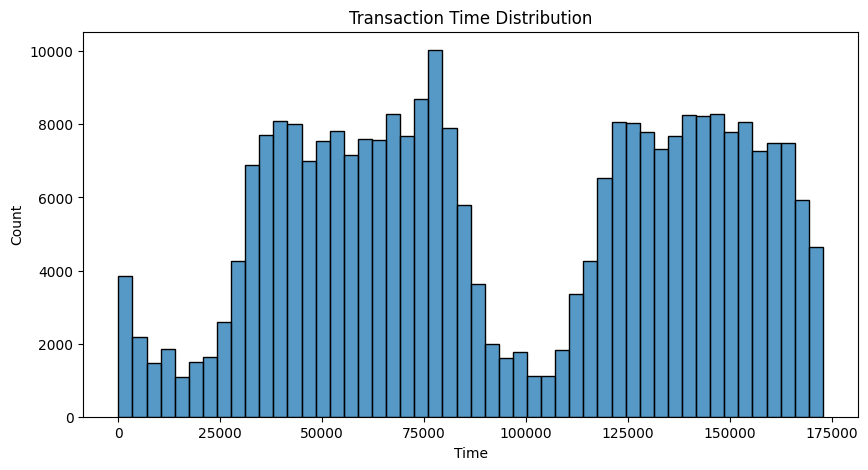

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Time"],
    bins=50
)

plt.title("Transaction Time Distribution")

plt.show()

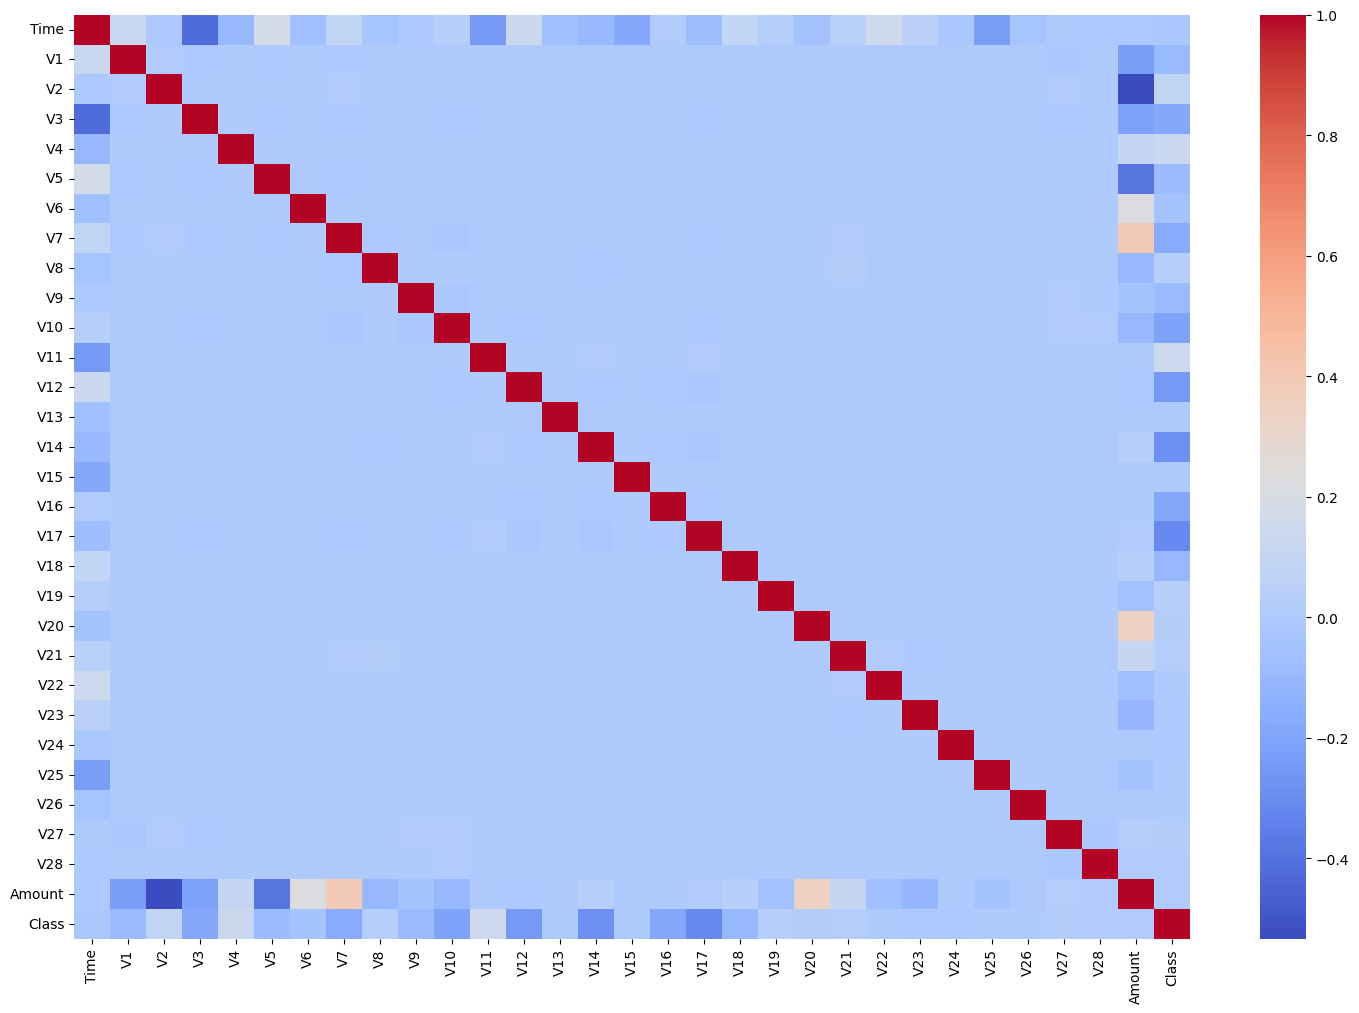

In [14]:
plt.figure(figsize=(18,12))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.show()

In [15]:
scaler = StandardScaler()

df["Amount"] = scaler.fit_transform(
    df[["Amount"]]
)

df["Time"] = scaler.fit_transform(
    df[["Time"]]
)

In [16]:
scaler = StandardScaler()

df["Amount"] = scaler.fit_transform(
    df[["Amount"]]
)

df["Time"] = scaler.fit_transform(
    df[["Time"]]
)

In [17]:
X = df.drop(
    "Class",
    axis=1
)

y = df["Class"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [20]:
print(
    y_train_smote.value_counts()
)

Class
0    226602
1    226602
Name: count, dtype: int64


In [21]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_smote,
    y_train_smote
)

lr_pred = lr_model.predict(
    X_test
)

lr_prob = lr_model.predict_proba(
    X_test
)[:,1]

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
    n_jobs= -1,
    class_weight= "balanced"
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

rf_prob = rf_model.predict_proba(
    X_test
)[:,1]

In [ ]:
scale_pos_weight = (
    y_train.value_counts()[0]
    /
    y_train.value_counts()[1]
)
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree = 0.8,
    scale_pos_weight= scale_pos_weight,
    max_depth=4,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

xgb_prob = xgb_model.predict_proba(
    X_test
)[:,1]

In [24]:
def evaluate_model(
    y_true,
    y_pred,
    y_prob
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )

    return [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]

In [25]:
results = pd.DataFrame(
    columns=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
)

results.loc["Logistic"] = evaluate_model(
    y_test,
    lr_pred,
    lr_prob
)

results.loc["Random Forest"] = evaluate_model(
    y_test,
    rf_pred,
    rf_prob
)

results.loc["XGBoost"] = evaluate_model(
    y_test,
    xgb_pred,
    xgb_prob
)

results

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic,0.973725,0.053137,0.873684,0.100181,0.961850
Random Forest,0.999489,0.923077,0.757895,0.832370,0.963964
XGBoost,0.998996,0.666667,0.800000,0.727273,0.967109


In [26]:
results.sort_values(
    by="ROC-AUC",
    ascending=False
)


,Accuracy,Precision,Recall,F1,ROC-AUC
XGBoost,0.998996,0.666667,0.800000,0.727273,0.967109
Random Forest,0.999489,0.923077,0.757895,0.832370,0.963964
Logistic,0.973725,0.053137,0.873684,0.100181,0.961850


In [27]:
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.67      0.80      0.73        95

    accuracy                           1.00     56746
   macro avg       0.83      0.90      0.86     56746
weighted avg       1.00      1.00      1.00     56746



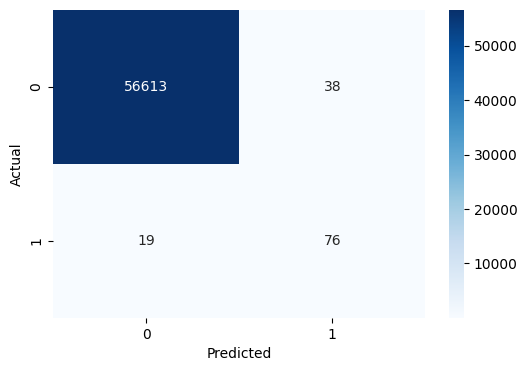

In [28]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

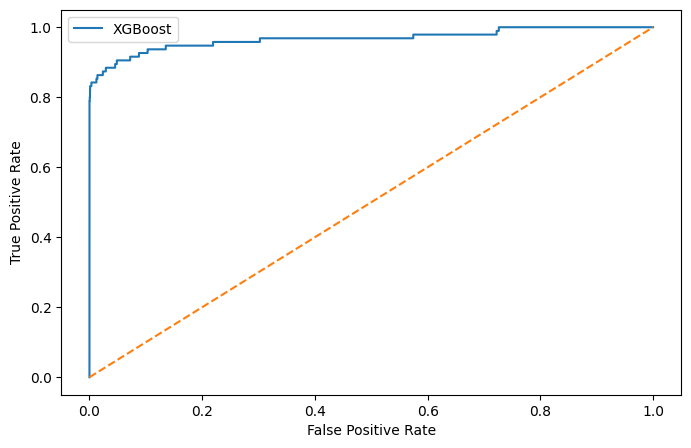

In [29]:
fpr, tpr, _ = roc_curve(
    y_test,
    xgb_prob
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label="XGBoost"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()


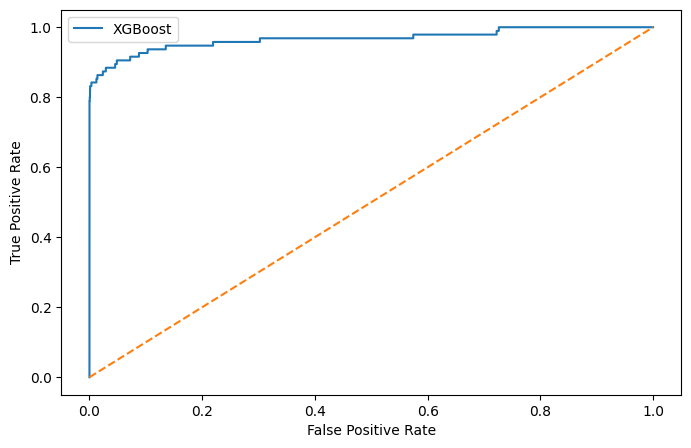

In [30]:
fpr, tpr, _ = roc_curve(
    y_test,
    xgb_prob
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label="XGBoost"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [31]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance":
    xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
14,V14,0.579220
4,V4,0.056938
8,V8,0.029602
10,V10,0.025797
12,V12,0.021636
17,V17,0.019900
13,V13,0.018334
29,Amount,0.017394
11,V11,0.016186
9,V9,0.014677


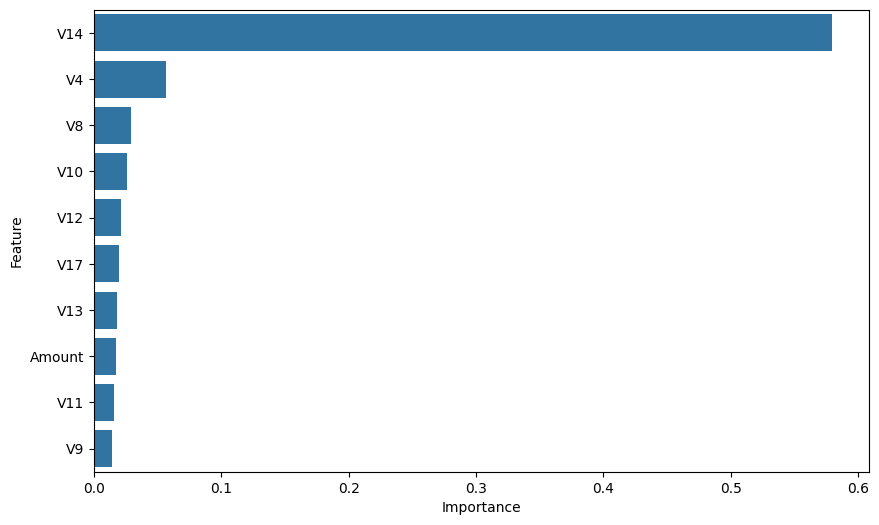

In [32]:
top_features = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.show()

In [33]:
risk_scores = (
    xgb_prob * 100
).round(2)

risk_scores[:10]

array([0.  , 0.  , 0.07, 0.  , 0.41, 0.02, 0.  , 0.  , 0.02, 0.  ],
      dtype=float32)

In [34]:
def risk_level(score):

    if score < 30:
        return "Low"

    elif score < 70:
        return "Medium"

    else:
        return "High"

In [35]:
risk_category = [
    risk_level(score)
    for score in risk_scores
]

pd.DataFrame({
    "Risk Score":
    risk_scores[:20],

    "Risk Level":
    risk_category[:20]
})

,Risk Score,Risk Level
0,0.00,Low
1,0.00,Low
2,0.07,Low
3,0.00,Low
4,0.41,Low
5,0.02,Low
6,0.00,Low
7,0.00,Low
8,0.02,Low
9,0.00,Low


In [36]:
joblib.dump(
    xgb_model,
    "fraud_model.pkl"
)

['fraud_model.pkl']

In [37]:
model = joblib.load(
    "fraud_model.pkl"
)

model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f